In [1]:
!pip install torch transformers pandas

In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import math

In [3]:
# from google.colab import drive
# drive.mount('/content/drive/',force_remount=False)

In [4]:
kaggle_df = pd.read_csv('/content/kaggle_df.csv')

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     1000 non-null   object 
 1   Display_Name                 1000 non-null   object 
 2   Gender                       1000 non-null   object 
 3   notebook_url                 1000 non-null   object 
 4   code_location                1000 non-null   object 
 5   labels                       1000 non-null   object 
 6   top_labels                   1000 non-null   object 
 7   code_sections                1000 non-null   object 
 8   markdown_sections            1000 non-null   object 
 9   all_sections                 1000 non-null   object 
 10  only_code_in_code_sections   1000 non-null   object 
 11  number_of_lines              1000 non-null   float64
 12  names_set                    1000 non-null   object 
 13  num_of_sections    

In [5]:
kaggle_df.drop_duplicates(subset=['only_code_in_code_sections'], inplace=True)

kaggle_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Username                     999 non-null    object 
 1   Display_Name                 999 non-null    object 
 2   Gender                       999 non-null    object 
 3   notebook_url                 999 non-null    object 
 4   code_location                999 non-null    object 
 5   labels                       999 non-null    object 
 6   top_labels                   999 non-null    object 
 7   code_sections                999 non-null    object 
 8   markdown_sections            999 non-null    object 
 9   all_sections                 999 non-null    object 
 10  only_code_in_code_sections   999 non-null    object 
 11  number_of_lines              999 non-null    float64
 12  names_set                    999 non-null    object 
 13  num_of_sections          

In [6]:
kaggle_df.Gender.value_counts()

,count
Gender,
male,564
female,435


In [7]:
kaggle_df.describe()

,number_of_lines,num_of_sections,token_count,variables_count,function_count,loop_count,condition_count,single_line_comment_density,function_density,loop_density,condition_density,comment_tokens_density,avg_var_name_length,comment_to_code_ratio,avg_func_length,code_to_markdown_ratio,avg_markdown_lines_length,markdown_sentiment
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,216.792793,23.531532,272.540541,121.866867,4.977978,6.716717,4.383383,0.107532,0.013926,0.023318,0.012729,0.174116,7.406865,4.021132,11.324837,497.786967,2.788292,0.120859
std,237.459812,25.783179,297.021480,89.071965,8.864574,9.743341,9.683165,0.102022,0.018750,0.027889,0.023138,0.175555,1.133259,113.080801,14.407308,1647.924114,3.339554,0.187629
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.000000,0.000280,0.000000,-0.919300
25%,75.500000,11.000000,147.000000,59.500000,0.000000,1.000000,0.000000,0.030419,0.000000,0.007463,0.000000,0.027988,6.660737,0.024245,0.000000,2.127067,1.000000,0.000000
50%,149.000000,19.000000,229.000000,100.000000,1.000000,4.000000,1.000000,0.081967,0.006969,0.016949,0.005587,0.125874,7.423611,0.152684,7.733333,6.838081,1.857143,0.062878
75%,267.000000,30.000000,335.000000,165.500000,6.000000,8.000000,5.000000,0.150067,0.021787,0.031402,0.018999,0.264690,8.062746,0.506117,17.246678,42.659779,3.825758,0.208990
max,2220.000000,629.000000,6143.000000,754.000000,88.000000,120.000000,120.000000,0.825000,0.147404,0.481928,0.481928,0.811765,17.230216,3574.500000,99.500000,22501.500000,47.000000,0.967450


In [8]:
def concatenate_code_sections(row, unique_char):
    code_list = eval(row)
    concatenated_code = unique_char.join(code_list)
    return concatenated_code

kaggle_df['parsed_code'] = kaggle_df['only_code_in_code_sections'].apply(concatenate_code_sections, unique_char=' ')

In [9]:
model_name = "neulab/codebert-python"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = kaggle_df['parsed_code'].tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-python and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

10

In [11]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.05, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 43 outliers.
Retained 956 code snippets.


In [12]:
# Remove outliers from the DataFrame
kaggle_df.reset_index(drop=True, inplace=True)
kaggle_df = kaggle_df[~kaggle_df.index.isin(outliers)]

kaggle_df.Gender.value_counts()

,count
Gender,
male,532
female,424


In [13]:
X=kaggle_df.drop('Gender',axis=1)
Y=kaggle_df.Gender

In [14]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.parsed_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [15]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [16]:
enc = LabelEncoder()
y_train = enc.fit_transform(y_train)
y_valid = enc.transform(y_valid)
y_test = enc.transform(y_test)

In [17]:
num_labels = len(enc.classes_)
num_labels

2

## CodeBert

In [18]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-python"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Using device: cuda


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at neulab/codebert-python and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [20]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text.reset_index(drop=True), y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text.reset_index(drop=True), y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text.reset_index(drop=True), y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
# Step 1: Calculate class weights based on your dataset
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)

# Step 2: Define a custom Trainer to incorporate class weights
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Define the weighted loss
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [22]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    report_to=['none'],
    num_train_epochs=30,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.05,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=1e-5,
    save_total_limit=2,
    metric_for_best_model='macro_f1',
    eval_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

In [23]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [24]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    # Compute basic metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro')
    }

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [26]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.728100,0.738307,0.447917,0.309353,0.277128,0.223958,0.500000
2,0.733700,0.715122,0.447917,0.309353,0.277128,0.223958,0.500000
3,0.702300,0.694223,0.520833,0.468975,0.451690,0.625579,0.559456
4,0.684900,0.680613,0.635417,0.592974,0.606665,0.651720,0.608381
5,0.699000,0.672023,0.645833,0.587879,0.603977,0.692480,0.613427
6,0.670400,0.663356,0.645833,0.601562,0.615397,0.670476,0.617815
7,0.677400,0.654225,0.656250,0.638974,0.647201,0.656250,0.640412
8,0.682200,0.642561,0.666667,0.654521,0.661269,0.664637,0.654234
9,0.664700,0.629653,0.677083,0.666629,0.672779,0.675000,0.665862
10,0.659300,0.615807,0.677083,0.666629,0.672779,0.675000,0.665862


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TrainOutput(global_step=378, training_loss=0.6348632170409753, metrics={'train_runtime': 646.3819, 'train_samples_per_second': 31.003, 'train_steps_per_second': 0.975, 'total_flos': 3163647329648640.0, 'train_loss': 0.6348632170409753, 'epoch': 18.0})

In [27]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

              precision    recall  f1-score   support

      female       0.67      0.66      0.66        85
        male       0.73      0.74      0.73       107

    accuracy                           0.70       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.70      0.70      0.70       192

f1_score_macro :  0.6988028072106784
f1_score_weighted :  0.7029370785743773


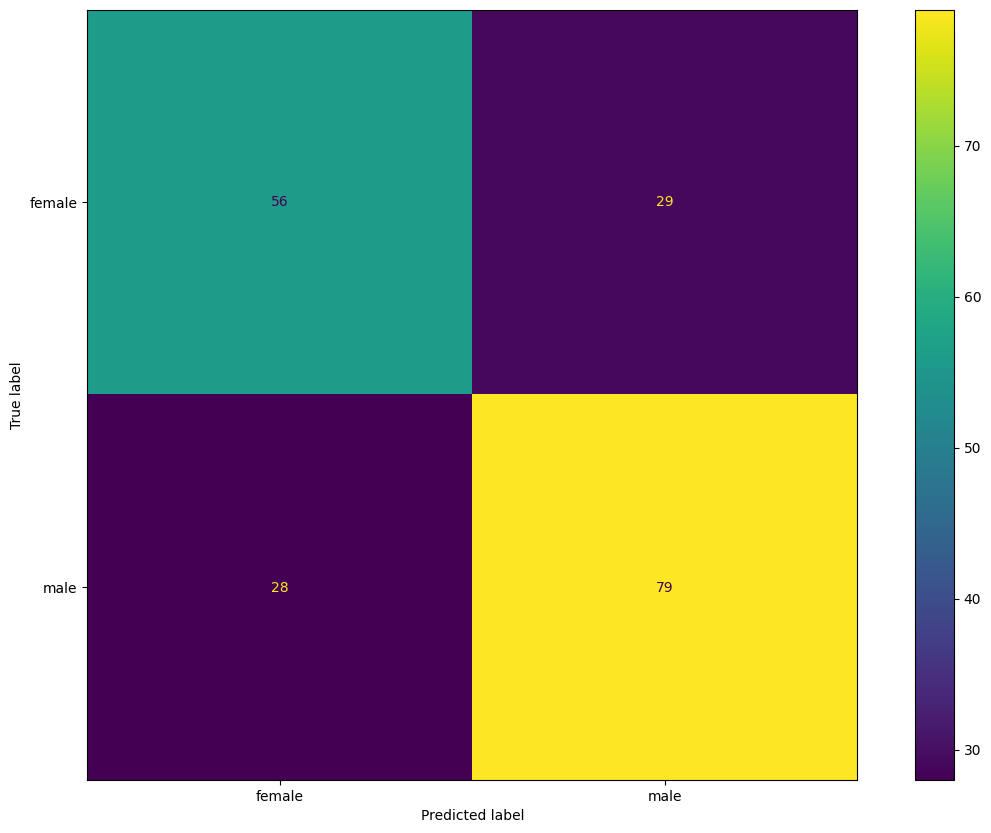

In [28]:
print(classification_report(y_true, y_codebert_test_pred, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_true, y_codebert_test_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [29]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

              precision    recall  f1-score   support

      female       0.69      0.76      0.72       296
        male       0.79      0.73      0.76       372

    accuracy                           0.74       668
   macro avg       0.74      0.75      0.74       668
weighted avg       0.75      0.74      0.74       668

f1_score_macro :  0.7427384209992905
f1_score_weighted :  0.7447977866098147


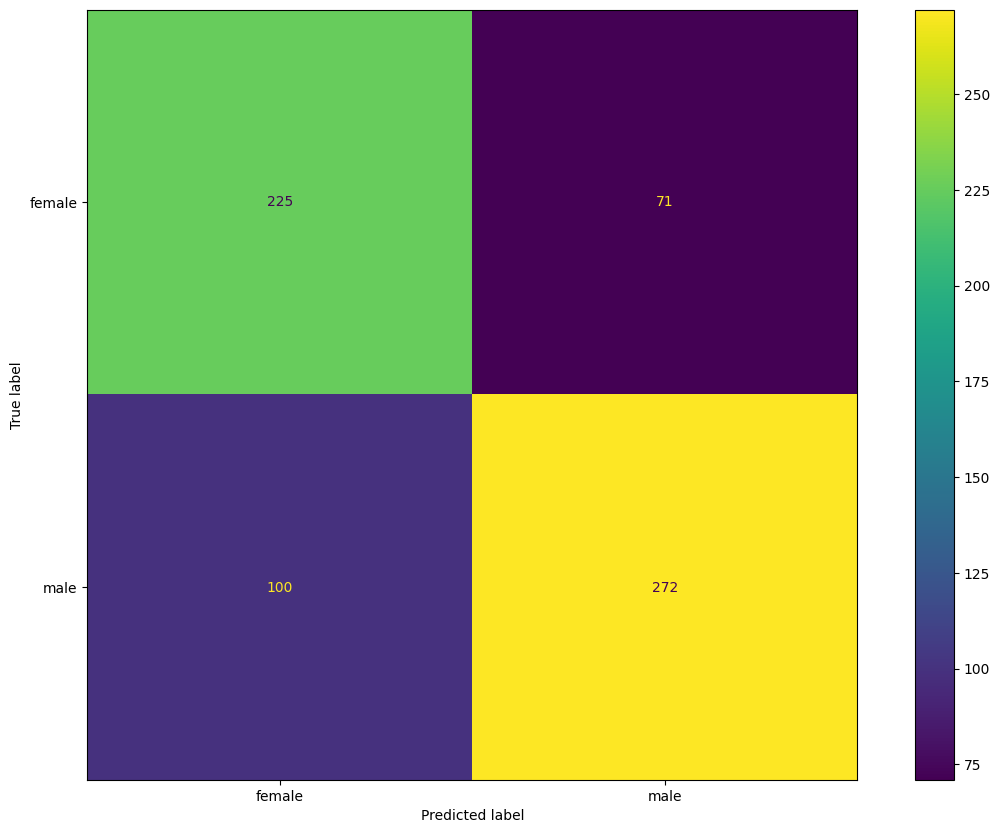

In [30]:
print(classification_report(y_true, y_codebert_train_pred, target_names=enc.classes_.tolist()))

print("f1_score_macro : ",f1_score(y_true, y_codebert_train_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_train_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=enc.classes_.tolist())

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()